In [3]:
# job role sugession dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import joblib
from collections import Counter

# Set plot style
plt.style.use('seaborn-v0_8')  # if available

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      1000 non-null   int64 
 1   skills            1000 non-null   object
 2   qualification     1000 non-null   object
 3   experience_level  1000 non-null   object
 4   job_role          1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB
None

First 5 Rows:
   candidate_id                                             skills  \
0             1  Python, SQL, TensorFlow, Machine Learning, Com...   
1             2             HTML, CSS, JavaScript, React, Teamwork   
2             3      Java, Spring, SQL, REST APIs, Problem Solving   
3             4          Figma, Adobe XD, UI/UX Design, Creativity   
4             5           Python, Django, JavaScript, React, Agile   

                        qualification experience_level  \
0        

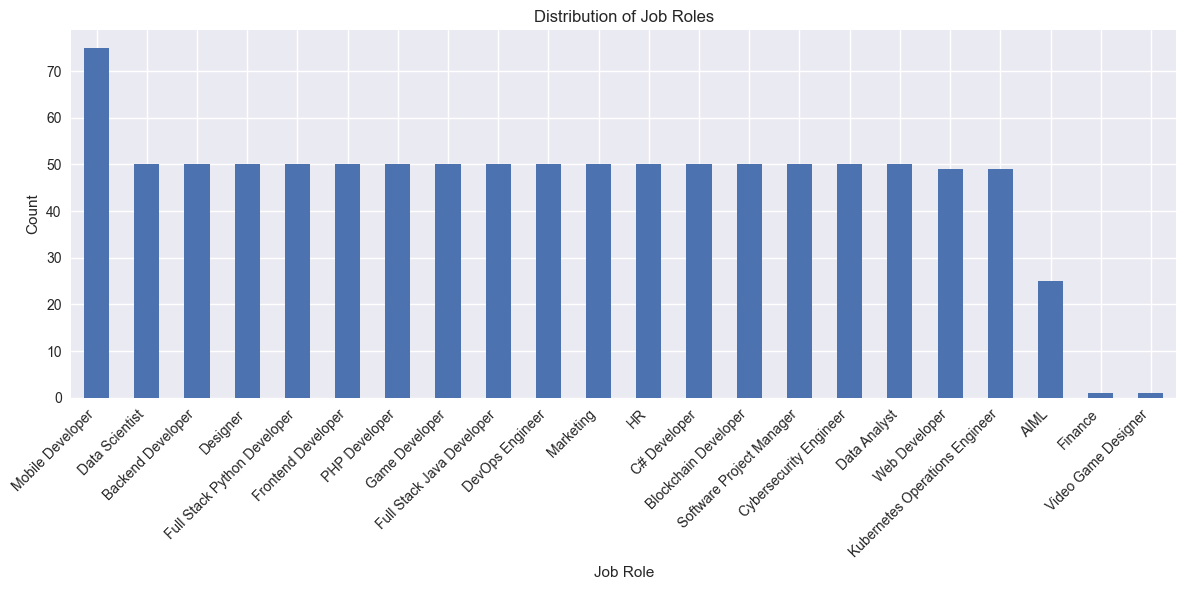


Experience Level Distribution:
experience_level
Mid       401
Senior    351
Entry     247
Entry,      1
Name: count, dtype: int64


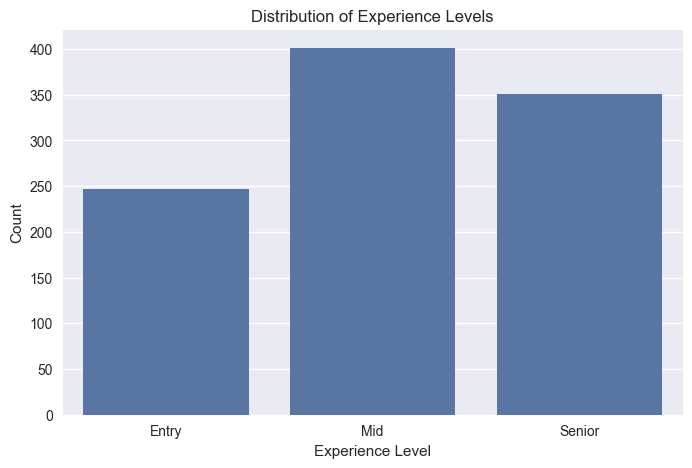


Qualification Distribution:
qualification
Bachelor's in Computer Science          349
Bachelor's in Information Technology     98
Bachelor's in Software Engineering       76
Master's in Data Science                 75
Bachelor's in Game Development           51
Master's in Human Resources              50
Bachelor's in Marketing                  50
Master's in Business Administration      50
Master's in Cybersecurity                49
Master's in Software Engineering         49
Bachelor's in Graphic Design             25
Bachelor's in Design                     25
PhD in Artificial Intelligence           25
Bachelor's in Statistics                 25
Master's in Computer Science              1
Master's in Finance                       1
Bachelor's in Cybersecurity               1
Name: count, dtype: int64


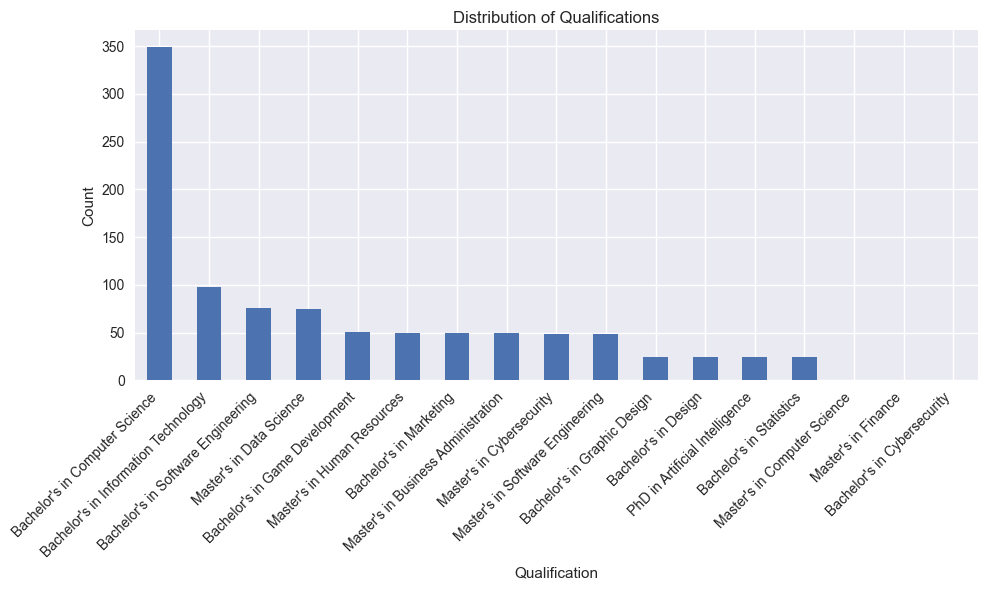


Top 10 Skills:
JavaScript    200
Python        150
SQL           148
Java          125
AWS           123
UI/UX          97
React          75
HTML           75
CSS            75
Docker         74
dtype: int64


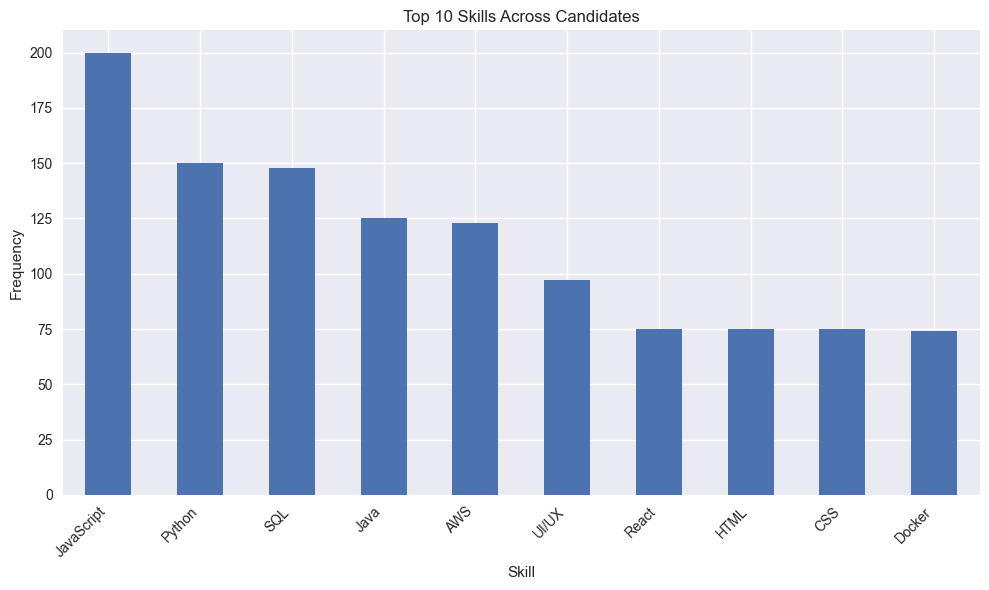


Top Skills for Data Scientist:
skills
Python              50
TensorFlow          26
Machine Learning    26
SQL                 25
Keras               25
R                   24
NLP                 23
Communication        1
Data Science         1
Name: count, dtype: int64


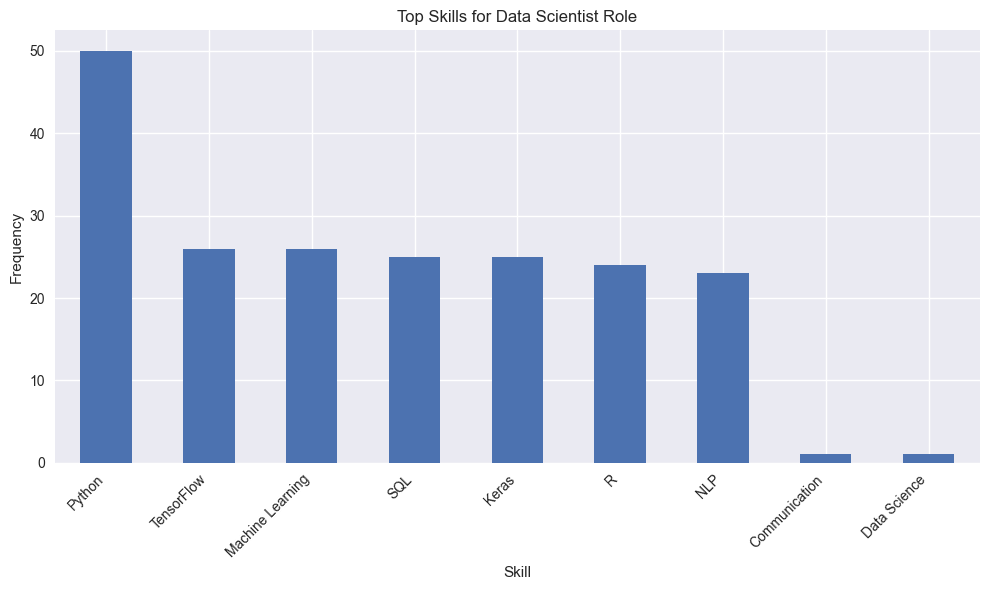

In [5]:
# DATA ANALISIS 

# Load the dataset
df = pd.read_csv('../dataset/candidate_job_role_dataset.csv')


# Display basic information
print("Dataset Info:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Class distribution of job_role
print("\nClass Distribution of Job Roles:")
print(df['job_role'].value_counts())

# Visualize job_role distribution
plt.figure(figsize=(12, 6))
df['job_role'].value_counts().plot(kind='bar')
plt.title('Distribution of Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Experience level distribution
print("\nExperience Level Distribution:")
print(df['experience_level'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='experience_level', order=['Entry', 'Mid', 'Senior'])
plt.title('Distribution of Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.show()

# Qualification distribution
print("\nQualification Distribution:")
print(df['qualification'].value_counts())
plt.figure(figsize=(10, 6))
df['qualification'].value_counts().plot(kind='bar')
plt.title('Distribution of Qualifications')
plt.xlabel('Qualification')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 10 skills
all_skills = [skill for skills in df['skills'].str.split(', ') for skill in skills]
skill_counts = Counter(all_skills)
top_skills = pd.Series(skill_counts).sort_values(ascending=False).head(10)
print("\nTop 10 Skills:")
print(top_skills)
plt.figure(figsize=(10, 6))
top_skills.plot(kind='bar')
plt.title('Top 10 Skills Across Candidates')
plt.xlabel('Skill')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Skills per job role (example for Data Scientist)
data_scientist_skills = df[df['job_role'] == 'Data Scientist']['skills'].str.split(', ').explode()
print("\nTop Skills for Data Scientist:")
print(data_scientist_skills.value_counts().head(10))
plt.figure(figsize=(10, 6))
data_scientist_skills.value_counts().head(10).plot(kind='bar')
plt.title('Top Skills for Data Scientist Role')
plt.xlabel('Skill')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Define a named tokenizer function to avoid pickling issues
def tokenize(text):
    return text.split(', ')

# Identify job roles with fewer than 15 instances
class_counts = df['job_role'].value_counts()
underrepresented = class_counts[class_counts < 15].index.tolist()

# Augment dataset by duplicating rows for underrepresented classes
if underrepresented:
    print(f"Underrepresented job roles (less than 15 instances): {underrepresented}")
    for role in underrepresented:
        # Get one row for the underrepresented role
        role_row = df[df['job_role'] == role].iloc[0]
        # Calculate how many duplicates are needed to reach at least 15 instances
        current_count = class_counts[role]
        needed = 15 - current_count
        # Duplicate the row 'needed' times
        new_rows = pd.DataFrame([role_row] * needed)
        df = pd.concat([df, new_rows], ignore_index=True)
    print("\nClass Distribution After Balancing:")
    print(df['job_role'].value_counts())

# Update candidate_id to ensure uniqueness
df['candidate_id'] = range(1, len(df) + 1)

# Save the balanced dataset
df.to_csv('candidate_job_role_dataset_balanced.csv', index=False)

# Prepare features and target
X = df[['skills', 'qualification', 'experience_level']]
y = df['job_role']

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

Underrepresented job roles (less than 15 instances): ['Finance', 'Video Game Designer']

Class Distribution After Balancing:
job_role
Mobile Developer                  75
Data Scientist                    50
Backend Developer                 50
Designer                          50
Full Stack Python Developer       50
Frontend Developer                50
PHP Developer                     50
Game Developer                    50
Full Stack Java Developer         50
DevOps Engineer                   50
Marketing                         50
HR                                50
C# Developer                      50
Blockchain Developer              50
Software Project Manager          50
Cybersecurity Engineer            50
Data Analyst                      50
Web Developer                     49
Kubernetes Operations Engineer    49
AIML                              25
Finance                           15
Video Game Designer               15
Name: count, dtype: int64


In [7]:
# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('skills', TfidfVectorizer(tokenizer=tokenize, lowercase=False, token_pattern=None), 'skills'),
        ('qualification', OneHotEncoder(handle_unknown='ignore'), ['qualification']),
        ('experience_level', OneHotEncoder(handle_unknown='ignore'), ['experience_level'])
    ])

# Define the Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the XGBoost pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=200, train_size=800, random_state=42, stratify=y_encoded)

# Define hyperparameter grids
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.1, 0.3]
}

# Train Random Forest
print("Training Random Forest Classifier...")
rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Get the best Random Forest model
best_rf_model = rf_grid_search.best_estimator_
rf_y_pred = best_rf_model.predict(X_test)

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"\nRandom Forest Test Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Best Parameters:", rf_grid_search.best_params_)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred, target_names=label_encoder.classes_))

# Train XGBoost
print("\nTraining XGBoost Classifier...")
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Get the best XGBoost model
best_xgb_model = xgb_grid_search.best_estimator_
xgb_y_pred = best_xgb_model.predict(X_test)

# Evaluate XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print(f"\nXGBoost Test Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Best Parameters:", xgb_grid_search.best_params_)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_y_pred, target_names=label_encoder.classes_))

# Select the best model
best_model = best_rf_model if rf_accuracy >= xgb_accuracy else best_xgb_model
best_model_name = "Random Forest" if rf_accuracy >= xgb_accuracy else "XGBoost"
best_y_pred = rf_y_pred if rf_accuracy >= xgb_accuracy else xgb_y_pred
print(f"\nBest Model: {best_model_name} with Test Accuracy: {max(rf_accuracy, xgb_accuracy):.4f}")

Training Random Forest Classifier...

Random Forest Test Accuracy: 0.9850

Random Forest Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Random Forest Classification Report:
                                precision    recall  f1-score   support

                          AIML       1.00      1.00      1.00         5
             Backend Developer       1.00      1.00      1.00        10
          Blockchain Developer       1.00      1.00      1.00         9
                  C# Developer       1.00      1.00      1.00        10
        Cybersecurity Engineer       1.00      0.90      0.95        10
                  Data Analyst       1.00      1.00      1.00        10
                Data Scientist       1.00      1.00      1.00         9
                      Designer       1.00      1.00      1.00        10
               DevOps Engineer       0.91      1.00      0.95        10

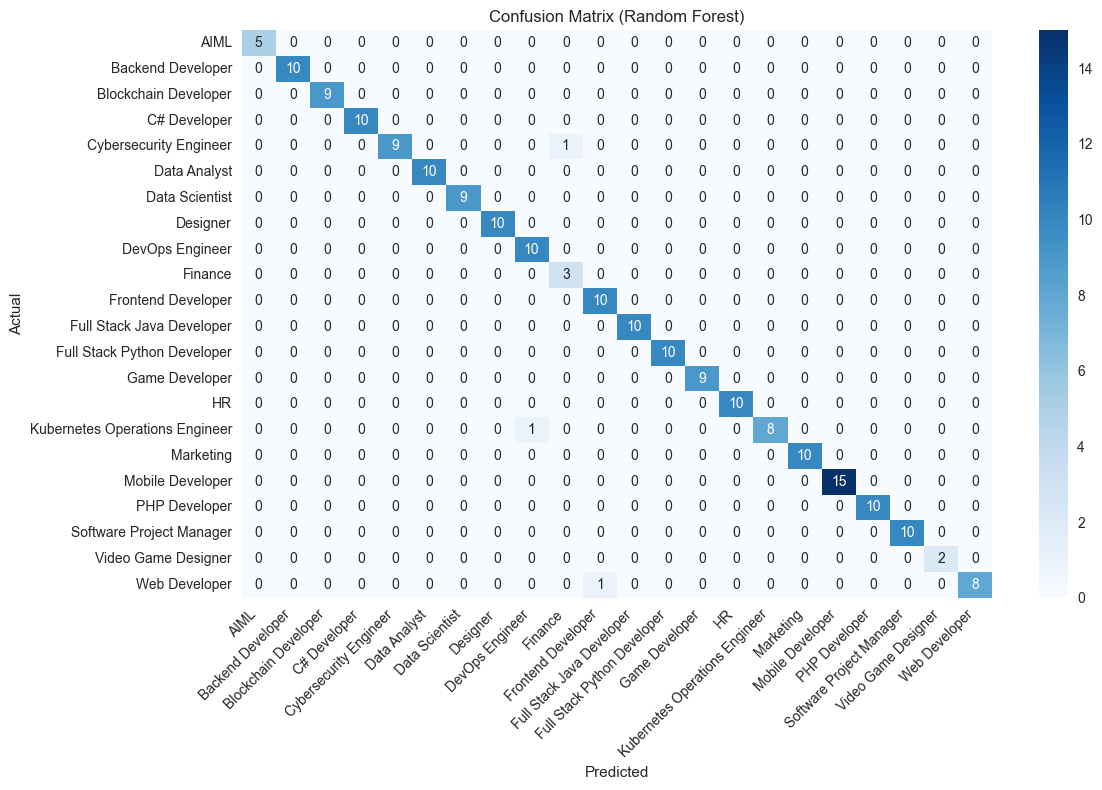

In [8]:
# Plot confusion matrix for the best model
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

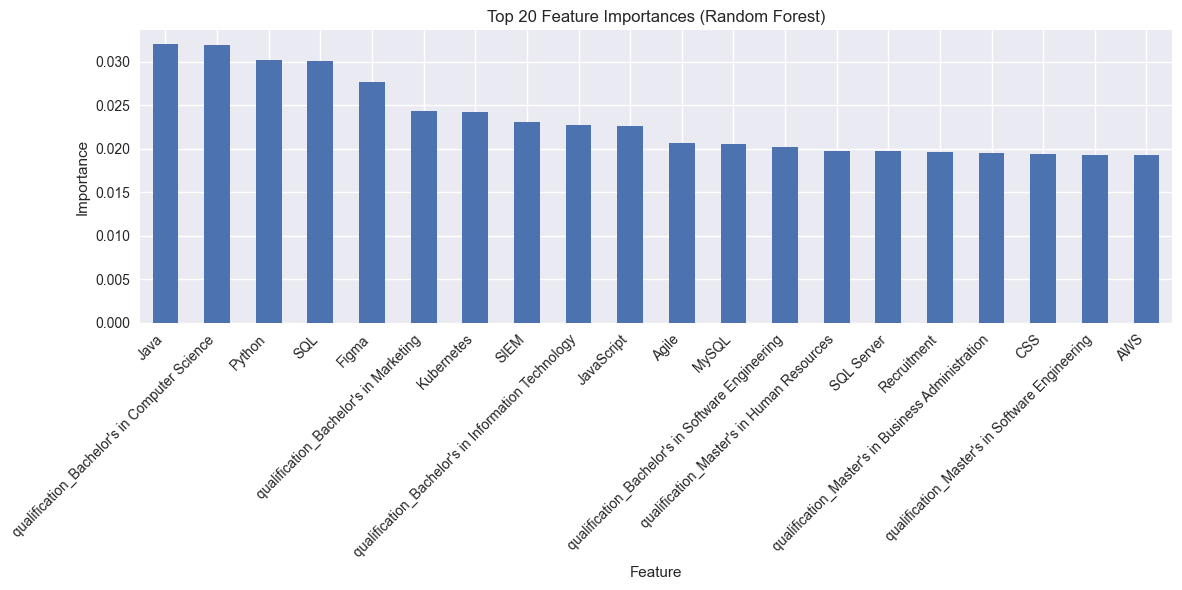


Top 10 Features:
Java                                                  0.031982
qualification_Bachelor's in Computer Science          0.031937
Python                                                0.030211
SQL                                                   0.030053
Figma                                                 0.027600
qualification_Bachelor's in Marketing                 0.024373
Kubernetes                                            0.024204
SIEM                                                  0.023005
qualification_Bachelor's in Information Technology    0.022737
JavaScript                                            0.022611
dtype: float64

Model and label encoder saved successfully.

Predicted Job Role for New Candidate: Full Stack Java Developer


In [20]:
# Feature Importance (for Random Forest)
if best_model_name == "Random Forest":
    # Get feature names from preprocessor
    tfidf_features = best_model.named_steps['preprocessor'].named_transformers_['skills'].get_feature_names_out()
    qual_features = best_model.named_steps['preprocessor'].named_transformers_['qualification'].get_feature_names_out()
    exp_features = best_model.named_steps['preprocessor'].named_transformers_['experience_level'].get_feature_names_out()
    feature_names = np.concatenate([tfidf_features, qual_features, exp_features])

    # Get feature importance
    importances = best_model.named_steps['classifier'].feature_importances_
    feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    # Plot top 20 features
    plt.figure(figsize=(12, 6))
    feature_importance.head(20).plot(kind='bar')
    plt.title('Top 20 Feature Importances (Random Forest)')
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\nTop 10 Features:")
    print(feature_importance.head(10))

# Save the best model and label encoder
joblib.dump(best_model, 'job_role_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("\nModel and label encoder saved successfully.")

# Example prediction
new_candidate = pd.DataFrame({
    'skills': ['Python,Pandas,SQL,Data Visualization'],
    'qualification': ["Masters's in Computer Science"],
    'experience_level': ['entry']
})
predicted_role = best_model.predict(new_candidate)
print(f"\nPredicted Job Role for New Candidate: {label_encoder.inverse_transform(predicted_role)[0]}")
